In [ ]:
import pandas as pd # 데이터 처리 라이브러리
import matplotlib.pyplot as plt # 시각화 라이브러리

In [ ]:
# read source data
tmp = pd.read_csv(
  'source_data/아파트(매매)_실거래가/아파트(매매)_실거래가_20260412173112.csv', # 파일 경로
  encoding='cp949', # 인코딩 방식
  dtype='string', # 모든 열을 문자열로 읽기
  na_values='-', # 결측값으로 처리할 문자열
  skiprows=15 # 헤더가 시작되는 행 번호 (0부터 시작, 15는 16번째 행)
)

tmp # 데이터 확인

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,경기도 평택시 소사동,697,0697,0000,평택효성해링턴플레이스2단지,72.7680,202101,31,"31,000",<NA>,13,<NA>,<NA>,2019,소사3로 22,<NA>,<NA>,<NA>,<NA>
1,2,경기도 평택시 동삭동,854,0854,0000,평택센트럴자이 4단지,75.7115,202101,31,"49,000",<NA>,6,<NA>,<NA>,2018,상서재로 50,<NA>,<NA>,<NA>,<NA>
2,3,울산광역시 울주군 온양읍 망양리,가-5-1,0005,0001,회야리버,45.0730,202101,31,"7,500",<NA>,6,<NA>,<NA>,2000,원동2길 19-1,<NA>,<NA>,<NA>,<NA>
3,4,경상남도 김해시 부원동,601-22,0601,0022,편한세상,39.4700,202101,31,"10,200",<NA>,8,<NA>,<NA>,2016,가락로29번길 10,20220129,<NA>,<NA>,<NA>
4,5,전북특별자치도 부안군 부안읍 선은리,258-1,0258,0001,대림낭주골,59.9250,202101,31,"8,200",<NA>,17,<NA>,<NA>,1997,낭주길 5,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62546,62547,경기도 화성시 동탄구 청계동,512,0512,0000,동탄역 시범우남퍼스트빌아파트,73.9600,202101,01,"99,500",<NA>,8,<NA>,<NA>,2015,동탄대로시범길 276,<NA>,<NA>,<NA>,<NA>
62547,62548,서울특별시 구로구 신도림동,640,0640,0000,신성은하수,59.8800,202101,01,"77,500",<NA>,11,<NA>,<NA>,1997,경인로66길 5,<NA>,<NA>,<NA>,<NA>
62548,62549,충청북도 제천시 청전동,4,0004,0000,주공,41.9800,202101,01,"1,600",<NA>,5,<NA>,<NA>,1980,청전대로15길 70,<NA>,<NA>,<NA>,<NA>
62549,62550,경기도 화성시 효행구 기안동,895,0895,0000,기안마을풍성신미주,84.8008,202101,01,"20,800",<NA>,1,<NA>,<NA>,2004,융건로 99,<NA>,<NA>,<NA>,<NA>


In [ ]:
tmp.info() # 데이터 구조 확인

<class 'pandas.DataFrame'>
RangeIndex: 62551 entries, 0 to 62550
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   NO        62551 non-null  string
 1   시군구       62551 non-null  string
 2   번지        62551 non-null  string
 3   본번        62551 non-null  string
 4   부번        62551 non-null  string
 5   단지명       62551 non-null  string
 6   전용면적(㎡)   62551 non-null  string
 7   계약년월      62551 non-null  string
 8   계약일       62551 non-null  string
 9   거래금액(만원)  62551 non-null  string
 10  동         0 non-null      string
 11  층         62551 non-null  string
 12  매수자       0 non-null      string
 13  매도자       0 non-null      string
 14  건축년도      62551 non-null  string
 15  도로명       62551 non-null  string
 16  해제사유발생일   3051 non-null   string
 17  거래유형      0 non-null      string
 18  중개사소재지    0 non-null      string
 19  등기일자      0 non-null      string
dtypes: string(20)
memory usage: 9.5 MB


In [ ]:
# 수도권/비수도권 분류
tmp['sido_nm'] = [ # 시도 이름 추출
  sgg.split(' ')[0]
  for sgg
  in tmp['시군구']
]

tmp['is_sdg'] = [ # 수도권 여부 표시
  sido_nm in ('서울특별시','인천광역시','경기도')
  for sido_nm
  in tmp['sido_nm']
]

In [ ]:
# 수도권/비수도권 개수 확인
print(
  '수도권 목록:\n',
  tmp[tmp['is_sdg'] == True]['sido_nm'].value_counts()
)
print(
  '비수도권 목록:\n',
  tmp[tmp['is_sdg'] == False]['sido_nm'].value_counts()
)

수도권 목록:
 sido_nm
경기도      20308
서울특별시     5956
인천광역시     4761
Name: count, dtype: int64
비수도권 목록:
 sido_nm
경상남도       4362
경상북도       3476
충청남도       3159
충청북도       3038
부산광역시      3036
강원특별자치도    2521
전북특별자치도    2224
대구광역시      2147
대전광역시      1923
광주광역시      1861
전라남도       1668
울산광역시      1248
세종특별자치시     455
제주특별자치도     408
Name: count, dtype: int64


In [ ]:
# 계약년월과 계약일을 합쳐서 날짜로 변환
tmp['contract_dt'] = pd.to_datetime(tmp['계약년월']+tmp['계약일']) # 계약년월과 계약일을 합쳐서 날짜로 변환
tmp['contract_ym'] = tmp['contract_dt'].dt.to_period('M') # 계약년월을 월 단위로 변환 (예: 2023-01, 2023-02 등)

tmp['contract_ym'].value_counts() # 계약년월별 거래 건수 확인

contract_ym
2021-01    62551
Freq: M, Name: count, dtype: int64

In [ ]:
# 거래금액(만원)을 숫자로 변환
tmp['deal_amount'] = tmp['거래금액(만원)'].str.replace(',', '').astype('int64')*10_000

In [ ]:
# 거래금액 통계 확인
tmp['deal_amount'].describe()

count    6.255100e+04
mean     3.645350e+08
std      3.679746e+08
min      4.000000e+06
25%      1.500000e+08
50%      2.500000e+08
75%      4.480000e+08
max      5.750000e+09
Name: deal_amount, dtype: float64

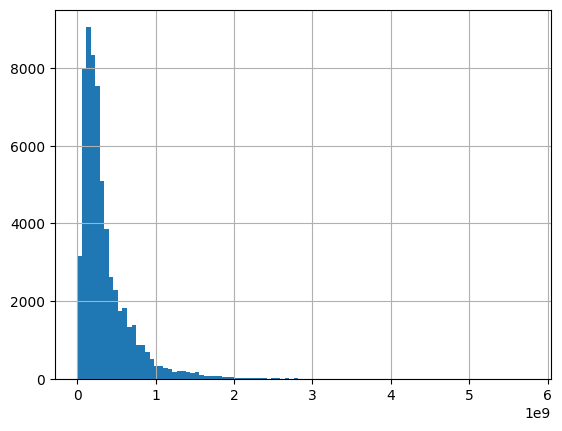

In [ ]:
# 거래금액 분포 시각화
tmp['deal_amount'].hist(bins=100)
plt.show()

In [ ]:
# 유효하지 않은 데이터 제거
tmp_valid = tmp[tmp['해제사유발생일'].isna()]

len(tmp_valid)

59500

In [ ]:
# 유효한 데이터 확인
tmp_valid[['sido_nm','is_sdg','contract_ym','deal_amount']]

,sido_nm,is_sdg,contract_ym,deal_amount
0,경기도,True,2021-01,310000000
1,경기도,True,2021-01,490000000
2,울산광역시,False,2021-01,75000000
4,전북특별자치도,False,2021-01,82000000
5,전북특별자치도,False,2021-01,30000000
...,...,...,...,...
62546,경기도,True,2021-01,995000000
62547,서울특별시,True,2021-01,775000000
62548,충청북도,False,2021-01,16000000
62549,경기도,True,2021-01,208000000


In [ ]:
# 수도권/비수도권과 계약년월별 거래 건수와 거래금액 중앙값 확인
tmp_valid[['sido_nm','is_sdg','contract_ym','deal_amount']].groupby(['is_sdg','contract_ym']).agg(
    deal_count = ('is_sdg','count'),
    amount_median = ('deal_amount','median'),
).reset_index()

,is_sdg,contract_ym,deal_count,amount_median
0,False,2021-01,29998,178000000.0
1,True,2021-01,29502,397000000.0
